# Introduction to neural network classification with TensorFlow

In this notebook we're going to learn how to write neural networks for classification problems using TensorFlow

A Classification is where you try to classify something as one thing or another

Few types of classification:

* Binary classification
* Multiclass classification
* Multilabel classification

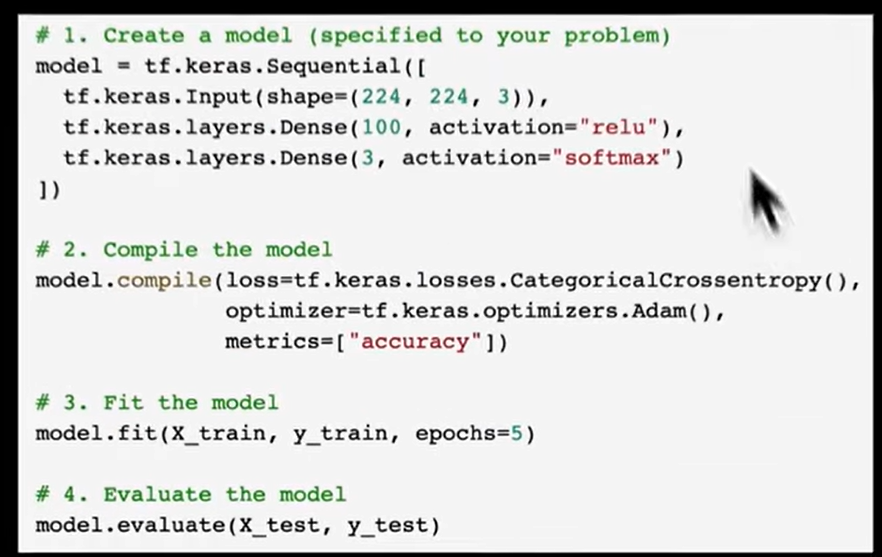

## Creating data to view and fit

In [1]:
from sklearn.datasets import make_circles

# Make 1000 examples
n_samples = 1000

X,y =make_circles(n_samples, noise=0.03,random_state=42)


In [2]:
# check out features
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [3]:
# check the labels
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0])

Our data is a little hard to understand right now ... let's visualize it!

In [4]:
import pandas as pd
circles = pd.DataFrame({"X0":X[:,0],"X":X[:,1], "label":y})
circles


,X0,X,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


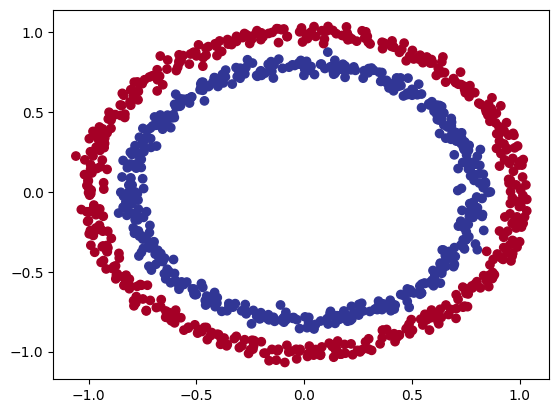

In [5]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu);

Playing around with https://playground.tensorflow.org/#activation=tanh&regularization=L1&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.00001&regularizationRate=0&noise=0&networkShape=4,2&seed=0.17893&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=true&ySquared=true&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false building and running different neural networks. See what happens when you change different hyperparameters.

### Input and out shapes

In [6]:
# Check the shapes of our features and labels
X.shape,y.shape

((1000, 2), (1000,))

In [7]:
# How many samples we're working with
len(X), len(y)

(1000, 1000)

In [8]:
# View the first example of features and labels
X[0], y[0]

(array([0.75424625, 0.23148074]), np.int64(1))

**Steps modelling**
The steps in modelling with TensorFlow are typically:

1. Create or import a model
2. Compile the model
3. Fit the model
4. evaluate the model
5. Tweak
6. Evaluate


In [9]:
import tensorflow as tf
# set the seed
tf.random.set_seed(42)

# 1. Craete a model using the Sequential API
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["accuracy"])

# 3. Fit the model
model_1.fit(X,y, epochs=5)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4420 - loss: 5.5276
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4541 - loss: 4.6373
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4676 - loss: 0.9102
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4763 - loss: 0.7409
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4777 - loss: 0.7123


In [10]:
# Let's try and improve our model by training for longer
model_1.fit(X,y, epochs=200,verbose=0)
model_1.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4852 - loss: 0.6927


[0.6932879686355591, 0.4729999899864197]

Since we're working on a binary classification problem and our model is getting around ~50% accuracy... it's performing as if it's guessing

So let's step things up and add extra layer

In [11]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create a model using Sequential with two layers
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model

model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["accuracy"])
# 3. Fit the model
model_2.fit(X,y,epochs=100, verbose=0)

In [12]:
model_2.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4955 - loss: 0.6930  


[0.6933743953704834, 0.5]

## Improving our model

let's look into our bag of tricks to see how we can improve our model.
1. Create a model - we might to add more layers or increase the number of hidden units within a layer
2. Compiling a model- here we might to choose a different optimization function such as Adam instead of SGD

3. Fitting a model - perhaps we might fit our model for more epochs(leave it training for longer).


In [13]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create the model (this time 3 layers)
model_3 =tf.keras.Sequential([
    tf.keras.layers.Dense(100), # add 100 dense nmeurons
    tf.keras.layers.Dense(10),  # add another layer with 10 neurons
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_3.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# 3. Fit the model
model_3.fit(X,y,epochs=100, verbose=0)

In [14]:
# Evaluate the model
model_3.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5060 - loss: 0.6914


[0.6964218616485596, 0.49300000071525574]

**To visualize our model's predictions, let's create a function plot_decision_boundary(), this function

* take in a trained model, features (X) and labels (y)
* Create a meshgrid of the different X values
* Make predictions across the meshgrid
* Plot the predictions as well as a line between zones (where each unique class falls)**

In [15]:
import numpy as np
import matplotlib.pyplot as plt


In [16]:
def plot_decision_boundary(model,X,y):
  """
  This function plots the decision boundary created by a model predicting on X.
  https://cs231n.github.io/neural-networks-case-study/#data

  Plots the decision boundary created by a model predicting on X.
  """

  # Define the axis
  x_min, x_max =X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
  y_min, y_max =X[:,1].min()- 0.1,X[:,1].max()+0.1
  xx,yy=np.meshgrid(np.linspace(x_min, x_max, 100),
                    np.linspace(y_min, y_max,100))

  # Create X value (we're going to make predictions on these)
  x_in = np.c_[xx.ravel(),yy.ravel()] # stack 2D arrays together

  y_pred = model.predict(x_in)

  # Check for multi-class
  if len(y_pred[0]) > 1:
    print("the process is using multiclass classification")
    # we have to reshape our prediction
    y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
  else:
    print("doing binary classification")
    y_pred = np.round(y_pred).reshape(xx.shape)

    #Plot the decision boundary
    plt.contourf(xx,yy,y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:,0], X[:,1],c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.xlim(yy.min(), yy.max())

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classification


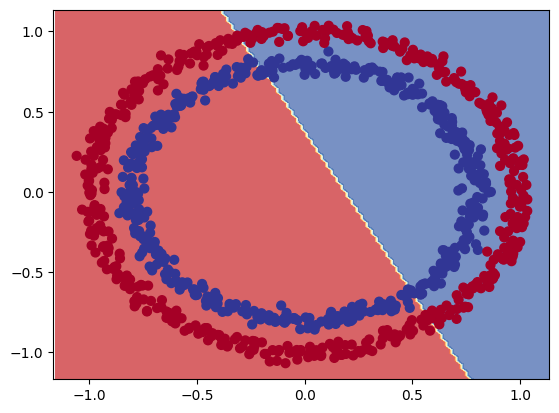

In [17]:
# Check out the prediction our model is making
plot_decision_boundary(model_3,
                       X=X,
                       y=y)

In [18]:
# Let's see if our model can be used for a regression problem

tf.random.set_seed(42)

# Create some regression data
X_regression = tf.range(0, 1000, 5)
y_regression = X_regression + 100 # y = X + 100
X_regression, y_regression

#Split our regression data into training and test sets
X_reg_train = X_regression[:150]
y_reg_train = y_regression[:150]
X_reg_test = X_regression[150:]
y_reg_test = y_regression[150:]

# Reshape X_reg_train and X_reg_test to be 2D (samples, features)
X_reg_train = tf.expand_dims(X_reg_train, axis=-1)
X_reg_test = tf.expand_dims(X_reg_test, axis=-1)


In [19]:
#Split our regression data into training and test sets
#X_reg_train = X_regression[:150]
#y_reg_train = y_regression[:150]
#X_reg_test = X_regression[150:]
#y_reg_test = y_regression[150:]

# Fit our model to the regression data

#model_3.fit(X_reg_train, y_reg_train, epochs=100)

Oh wait ... we compiled our model for binary classification problem

But... we're now working on a regression problem, let's change the model to suit our data

In [20]:
# setup random seed
tf.random.set_seed(42)

model_3 =tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_3.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["mae"])

# 3. Fit the model - Removed from here, fitting happens in the data preparation cell
model_3.fit(X_reg_train,y_reg_train, epochs=100)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 582.0052 - mae: 582.0052
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 463.6948 - mae: 463.6948
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 345.9366 - mae: 345.9366
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 227.0710 - mae: 227.0710
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 105.7371 - mae: 105.7371
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 53.6399 - mae: 53.6399 
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 83.5382 - mae: 83.5382 
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 66.9920 - mae: 66.9920 
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 43.1659 - mae: 43.1659
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 48.6450 - mae: 48.6450 
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 40.2571 - mae: 40.2571 
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 43.2790 - mae: 43.2790 
Epoch 13/100
5/

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


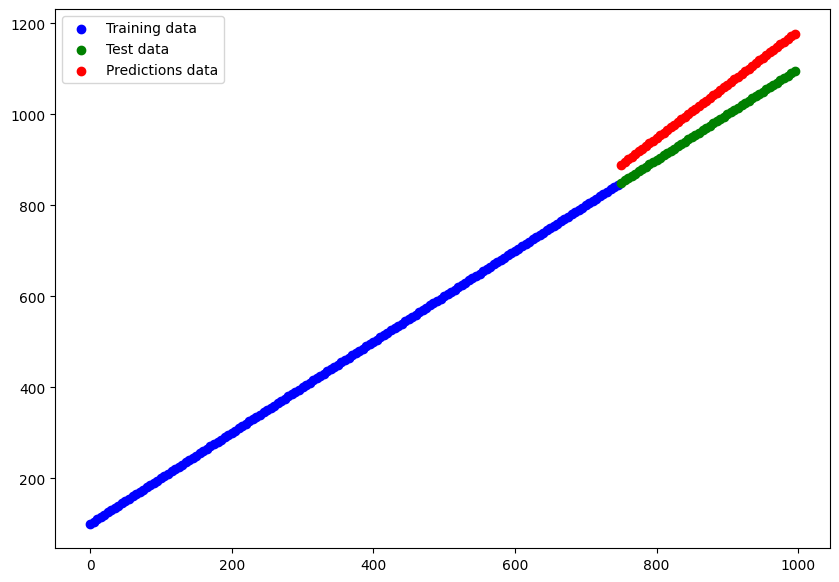

In [21]:
# Make predictions with our trained model
y_reg_preds = model_3.predict(X_reg_test)

#plot the model's predictions against the regression
plt.figure(figsize=(10,7))
plt.scatter(X_reg_train, y_reg_train, c="b", label="Training data")
plt.scatter(X_reg_test, y_reg_test, c="g", label="Test data")
plt.scatter(X_reg_test, y_reg_preds, c="r", label="Predictions data")
plt.legend();


## The missing piece: Non-linearity
**Straight Lines and Non-Straight Lines**

In [22]:
# Set the random seed
tf.random.set_seed(42)
# 1. Create the model
model_4 =tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.linear)
])

# 2. Compile the model
model_4.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=["accuracy"])
# Fit the model

history = model_4.fit(X,y, epochs=100)


Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5132 - loss: 6.0605
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5138 - loss: 6.0513 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5164 - loss: 6.0508
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5164 - loss: 6.0509
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5164 - loss: 6.0497
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5164 - loss: 6.0485
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5168 - loss: 6.0472 
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5168 - loss: 6.0460
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5168 - loss: 6.0448
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5176 - loss: 6.0252
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5145 - loss: 5.9646
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accurac

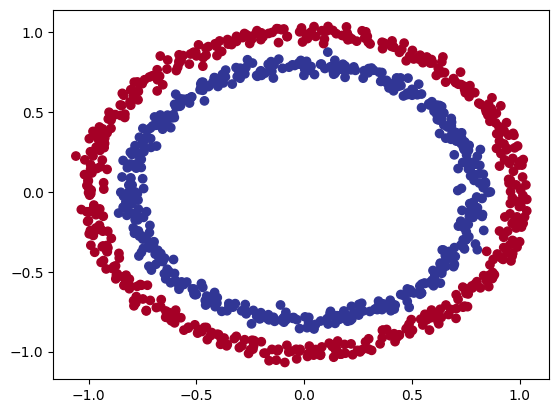

In [23]:
#Check out our data
plt.scatter(X[:,0], X[:, 1], c=y, cmap=plt.cm.RdYlBu);

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
doing binary classification


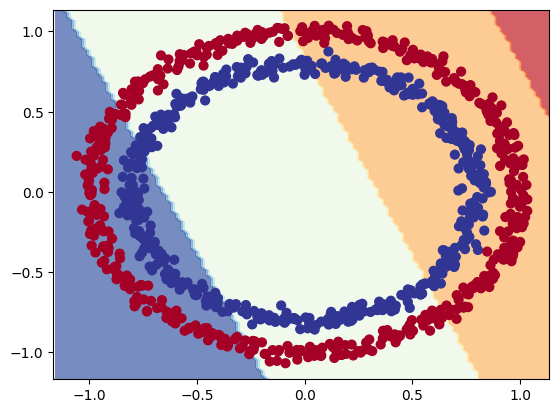

In [24]:
# Check the decision boundary
plot_decision_boundary(model_4,
                       X=X,
                       y=y)

## Building our First Neural Network with Non-linearity activation function

In [25]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model with a non-linear
model_5 =tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.relu)

])

# 2. Compile the model
model_5.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=["accuracy"])
# 3. Fit the model
history = model_5.fit(X,y, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4799 - loss: 6.2595
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4806 - loss: 6.2068 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4788 - loss: 6.1345
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4779 - loss: 6.1220 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4778 - loss: 6.1071
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4810 - loss: 6.0180
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4815 - loss: 5.9335
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4837 - loss: 5.9247
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4798 - loss: 5.9238
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4798 - loss: 5.9231 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4798 - loss: 5.9221
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accura

##When using the binary the output layer is **sigmoid**

In [26]:
# Time to replicate the multi-layer neural network from TensorFlow playground in code:

# Set the random seed
tf.random.set_seed(42)

# 1. Create the model
model_6 =tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid") # Changed to 1 output unit with sigmoid activation for binary classification
])

# 2. Compile the model
model_6.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=["accuracy"])

# 3. Fit the model
history = model_6.fit(X, y,epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5320 - loss: 0.6965
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5263 - loss: 0.6953
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5232 - loss: 0.6947
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5083 - loss: 0.6941
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5066 - loss: 0.6935
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5082 - loss: 0.6930
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4887 - loss: 0.6926
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4873 - loss: 0.6921
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4861 - loss: 0.6916
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4731 - loss: 0.6911
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4658 - loss: 0.6906
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy:

In [27]:
model_6.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9475 - loss: 0.2827


[0.28807467222213745, 0.9459999799728394]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
doing binary classification


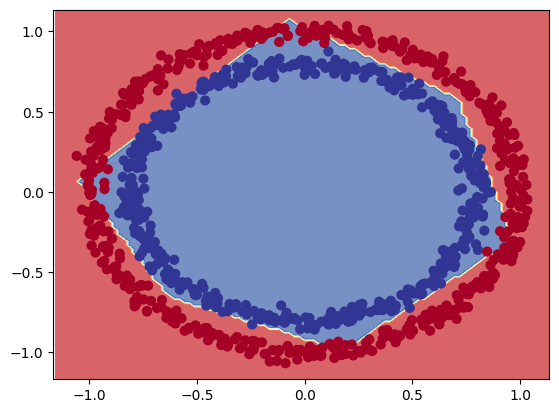

In [28]:
# How do our model prediction look?
plot_decision_boundary(model_6,
                       X=X,
                       y=y)

🤭 **Question:** what's wrong the prediction we've made? Are we really evaluating our model correctly? what data did the model learn on and data did we predict on?

🧑**Note:** The combination of **linear (straight lines) and non-linear (non-straight lines) functions** is one of the key fundamentals of neural networks.

Now we've discussed the concept of linear and non-linear functions (or lines), let's see them in actions

In [29]:
# Create a toy tensor (similar to the data we pass into our models)
A = tf.cast(tf.range(-10,10), tf.float32)
A

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.],
      dtype=float32)>

In [30]:
#plt.plot(A)
# Let's try the linear activation function
tf.keras.activations.linear(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.],
      dtype=float32)>

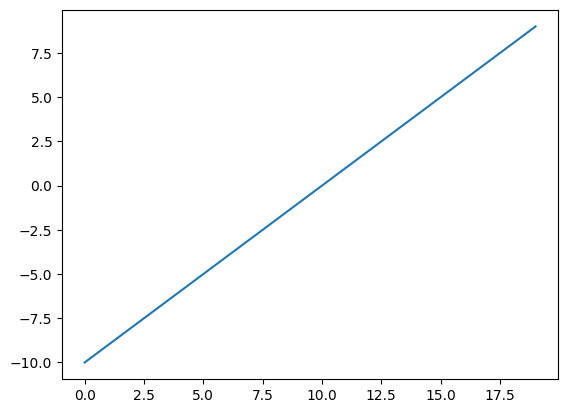

In [31]:
# Does the linear activation function change anything
plt.plot(tf.keras.activations.linear(A));

In [32]:
# Let's start by replicating sigmoid - sigmoid(x) = 1/(1 + exp(-x))
def sigmoid(x):
  return 1/(1 + tf.exp(-x))

  # Use the sigmoid function on our toy tensor
sigmoid(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([4.5397872e-05, 1.2339458e-04, 3.3535014e-04, 9.1105117e-04,
       2.4726233e-03, 6.6928510e-03, 1.7986210e-02, 4.7425874e-02,
       1.1920292e-01, 2.6894143e-01, 5.0000000e-01, 7.3105860e-01,
       8.8079703e-01, 9.5257413e-01, 9.8201376e-01, 9.9330717e-01,
       9.9752742e-01, 9.9908900e-01, 9.9966466e-01, 9.9987662e-01],
      dtype=float32)>

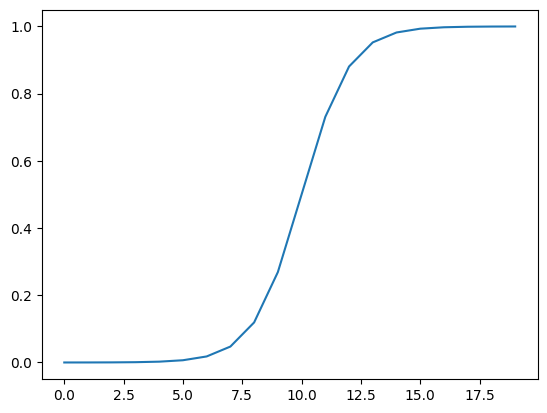

In [33]:
# Plot our toy tensor transformed by sigmoid
plt.plot(sigmoid(A));

In [34]:
# Let's recreate the relu function
def relu(x):
  return tf.maximum(0,x)

relu(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6.,
       7., 8., 9.], dtype=float32)>

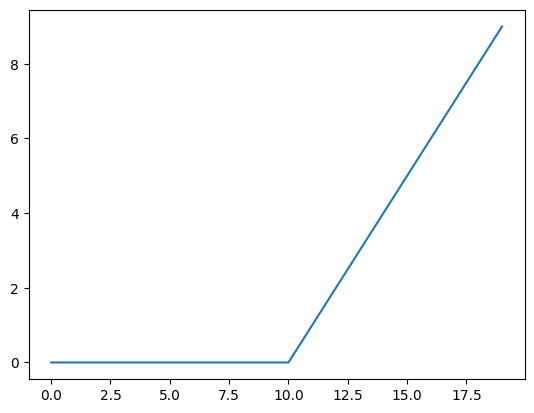

In [35]:
# Plot the relu function
plt.plot(relu(A));

**Activations function cheat cheat link below**
https://deep-learning-cheatsheet.readthedocs.io/en/latest/activation_functions.html#relu

## Evaluating and improving our classification

So far we've been training and testing on the same dataset

However, in machine learning this is basically a sin.

so let's create a training and test set

In [36]:
# check how many examples we have
len(X)

1000

In [37]:
# Split into train and test sets
X_train = X[:800]
y_train = y[:800]
X_test = X[800:]
y_test = y[800:]

In [38]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 2), (200, 2), (800,), (200,))

In [39]:
# Let's recreate a model to fit on the training data and evaluate the testing data

# set the random seed
tf.random.set_seed(42)

# 1. Create the model
model_7 =tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2. Compile the model
model_7.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=["accuracy"])

# 3. Fit the model
history=model_7.fit(X_train,y_train,epochs=25)

Epoch 1/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4876 - loss: 0.6948
Epoch 2/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5042 - loss: 0.6910 
Epoch 3/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4974 - loss: 0.6867 
Epoch 4/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5405 - loss: 0.6817 
Epoch 5/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5856 - loss: 0.6732 
Epoch 6/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5970 - loss: 0.6600 
Epoch 7/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6129 - loss: 0.6430 
Epoch 8/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6682 - loss: 0.6090 
Epoch 9/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7784 - loss: 0.5478 
Epoch 10/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8516 - loss: 0.4859 
Epoch 11/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9107 - loss: 0.4218 
Epoch 12/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0

In [40]:
model_7.evaluate(X_test,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9823 - loss: 0.0719  


[0.06793833523988724, 0.9850000143051147]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classification


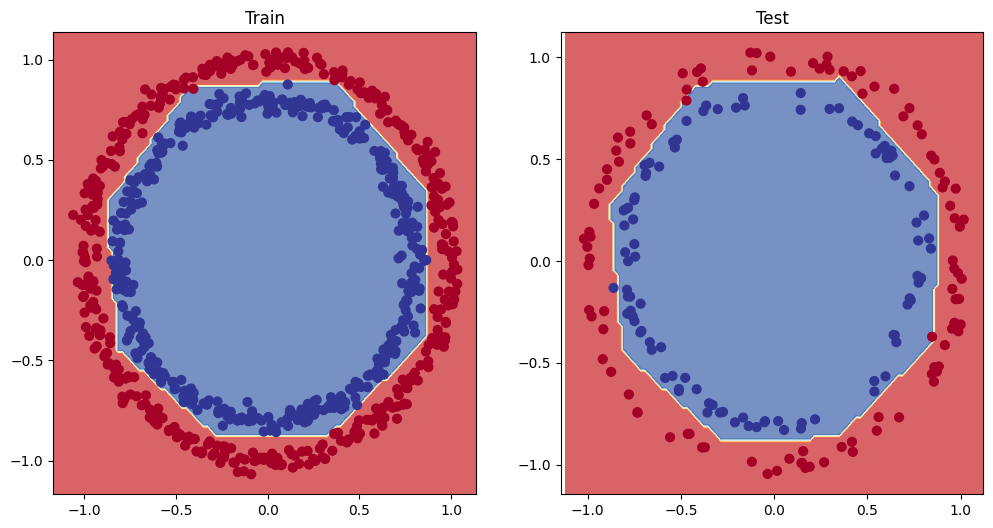

In [41]:
# Plot the decision boundaries for the training and test sets
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_7,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_7,X_test,y_test)
plt.show()



In [42]:
x_min, x_max =X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
y_min, y_max =X[:,1].min()- 0.1,X[:,1].max()+0.1
x_min, x_max, y_min, y_max

(np.float64(-1.1595024599098636),
 np.float64(1.1337117525463374),
 np.float64(-1.1677683182718437),
 np.float64(1.1360036756154805))

In [43]:
model_6.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113 (456.00 B)

 Trainable params: 37 (148.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 76 (308.00 B)

Plot the loss(or training)curves

In [44]:
# Convert the history object into a DataFrame
pd.DataFrame(history.history)

,accuracy,loss
0,0.47375,0.695281
1,0.52500,0.690351
2,0.51875,0.683631
3,0.58625,0.675209
4,0.61125,0.664432
5,0.62000,0.649183
6,0.63375,0.628762
7,0.70000,0.590561
8,0.80500,0.526357
9,0.87500,0.463744


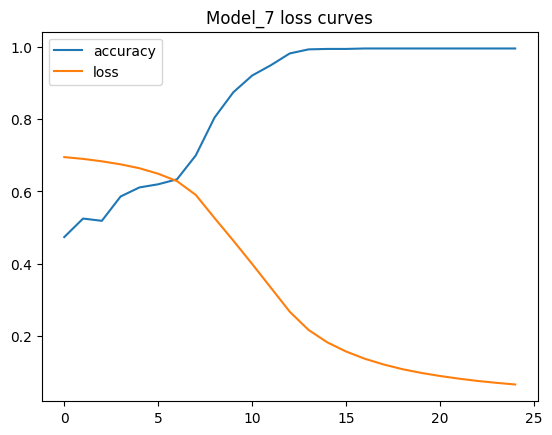

In [45]:
# Plot the loss curves
pd.DataFrame(history.history).plot()
plt.title("Model_7 loss curves")
plt.show()


**Note:** For many problems, the loss function go down means the model is improving (the predictions it's making are getting closer to the ground truth).

**USING CALLBACKS TO FIND A MODEL'S IDEAL LEARNING RATE**

## Finding the best learning rate

To find ideal learning rate (the learning rate where the loss decreases the most during training) we are going to use the following steps:

* A learning rate **callback** - you can think of a callback an extra piece of functionality, you can add to your *while* its training

* Another model ( we cpold use the same one as above, but we're practicing building models here)

* Modified loss curves plot

In [46]:
# Set random seed
tf.random.set_seed(42)

# Create a model
model_8 =tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")

])

# 2. Compile ther model
model_8.compile(loss="binary_crossentropy",
                optimizer="Adam",
                metrics=["accuracy"])

# Create a learning rate callback
lr_scheduler=tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch/20))

# Fit the model (passing lr_schedure callback)
history = model_8.fit(X_train,y_train, epochs=100, callbacks=[lr_scheduler])


Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4993 - loss: 0.7177 - learning_rate: 1.0000e-04
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4987 - loss: 0.7166 - learning_rate: 1.1220e-04
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5025 - loss: 0.7155 - learning_rate: 1.2589e-04
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4964 - loss: 0.7144 - learning_rate: 1.4125e-04
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4945 - loss: 0.7132 - learning_rate: 1.5849e-04
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4946 - loss: 0.7120 - learning_rate: 1.7783e-04
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4911 - loss: 0.7108 - learning_rate: 1.9953e-04
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4750 - loss: 0.7096 - learning_rate: 2.2387e-04
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4797 - loss: 0.7084 - learning

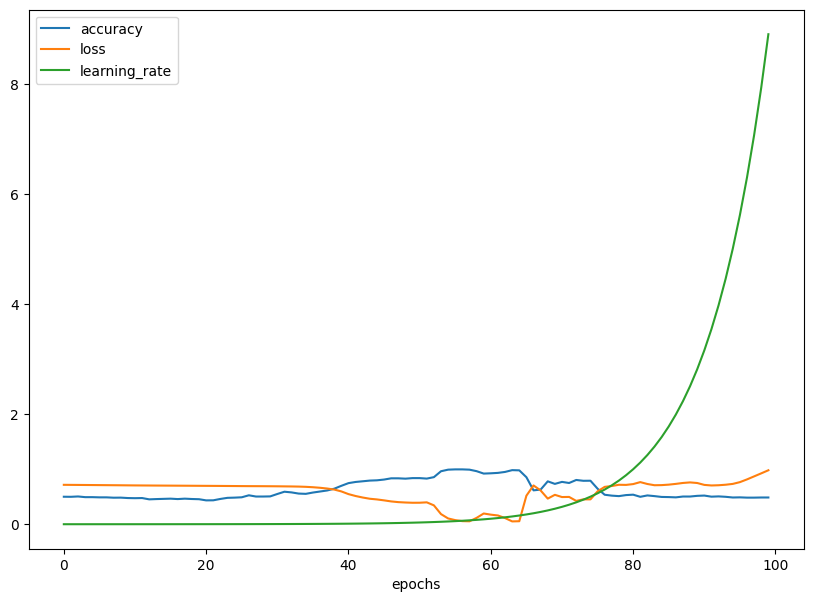

In [47]:
# Checkout the history
pd.DataFrame(history.history).plot(figsize=(10,7), xlabel="epochs");
plt.show()

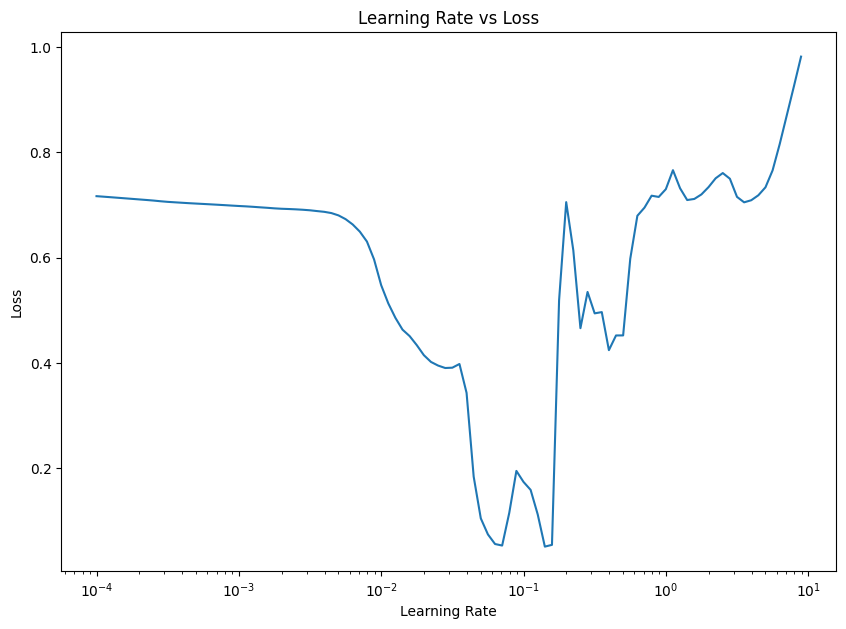

In [48]:
# Plot the learning rate versus the loss
lrs = 1e-4 * (10**(tf.range(100)/20))
plt.figure(figsize=(10,7))
plt.semilogx(lrs, history.history["loss"])
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning Rate vs Loss")
plt.show()

In [49]:
# Example of other typical learning rates values:
10**0, 10**-1, 10**-2, 10**-3, 1e-4

(1, 0.1, 0.01, 0.001, 0.0001)

In [50]:
# Let's try using a higher *ideal* learning rate with the same model

# Set random setseed
tf.random.set_seed(42)

# 1. Create a model

model_9 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile the model
model_9.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.02),
                metrics=["accuracy"])

# 3. fit the model
history_9 = model_9.fit(X_train, y_train, epochs=20)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4746 - loss: 0.6948
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5384 - loss: 0.6896 
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5784 - loss: 0.6783 
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6953 - loss: 0.6363 
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8039 - loss: 0.5484 
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9077 - loss: 0.4215 
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9547 - loss: 0.3063
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9879 - loss: 0.2188 
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9949 - loss: 0.1547 
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9913 - loss: 0.1175 
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9908 - loss: 0.0954 
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.

In [51]:
model_9.evaluate(X_test,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9981 - loss: 0.0277  


[0.030141104012727737, 0.9950000047683716]

In [52]:
model_8.evaluate(X_test,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5485 - loss: 0.7245  


[0.7641786932945251, 0.4950000047683716]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
doing binary classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classification


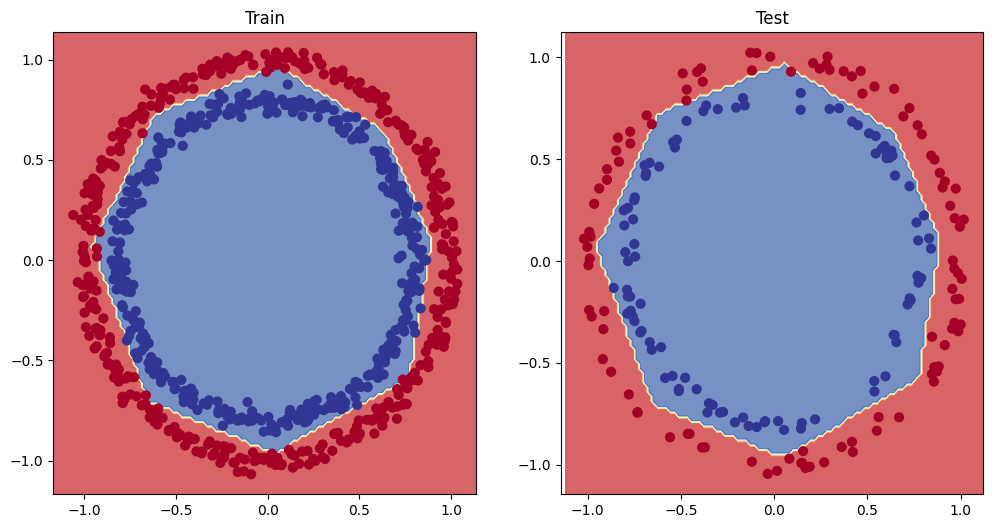

In [53]:
# Plot the decision boundaries for the training and test sets

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_9, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_9, X_test, y_test)
plt.show()

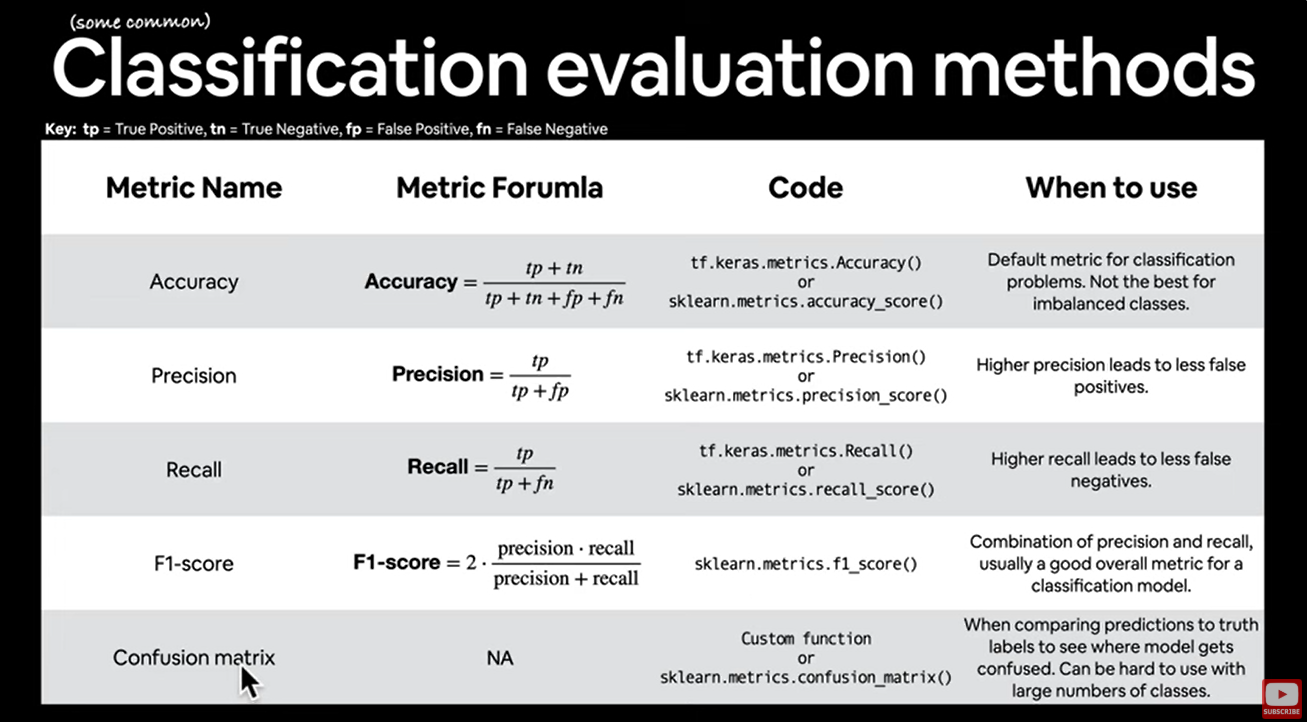

## More classification evaluation methods
Alongside visualizing our model as much as possible, there are handful of other classification evaluation methods & metrics you should be familiar with:
* Accuracy
* Precision
* Recall
* F1-score
* confusion matrix
* classification report (from sklearn) - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html


In [54]:
# Check the accuracy of our model
loss, accuracy = model_9.evaluate(X_test, y_test)
print(f"Model loss on the test set:{loss}")
print(f"Model accuracy on the test set:{(accuracy*100):.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9981 - loss: 0.0277 
Model loss on the test set:0.030141104012727737
Model accuracy on the test set:99.50%


## **How about the confusion Matrix**


In [55]:
# Create a confusion matrix
from sklearn.metrics import confusion_matrix

# Make predictions (removed from here)
y_preds = model_9.predict(X_test)


# Create confusion matrix (removed from here, moved to hJkOXMJsgXjm)
# confusion_matrix(y_test, y_preds)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [56]:
# Convert prediction probabilities to binary format and view the first 10
tf.round(y_preds)[:10]

<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
array([[1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.]], dtype=float32)>

In [57]:
# Create a confusion matrix
confusion_matrix(y_test, tf.round(y_preds))

array([[100,   1],
       [  0,  99]])

## How about we prettify our confusion matrix?

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


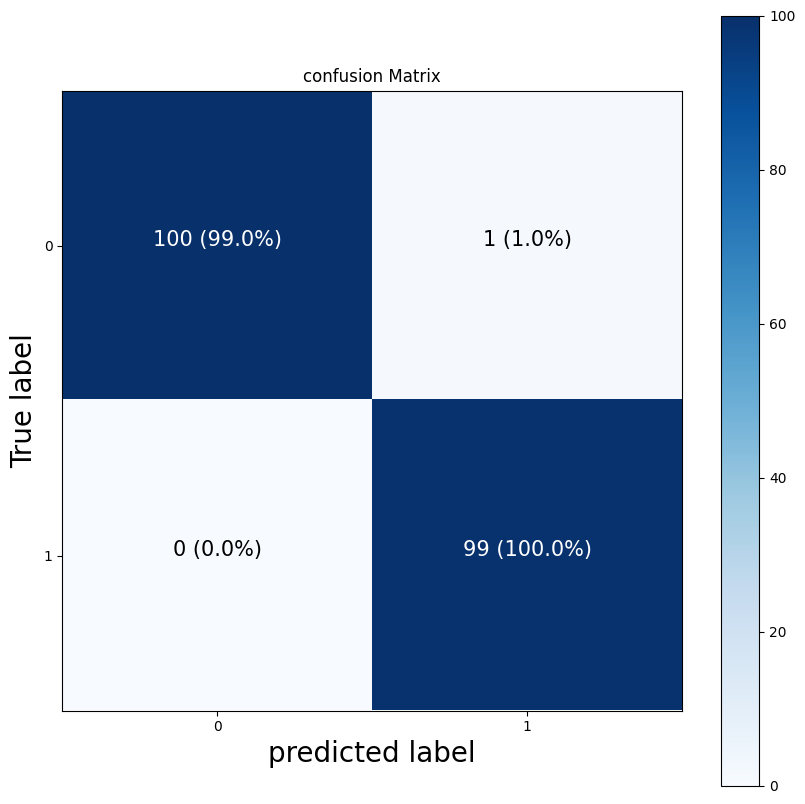

In [58]:
import itertools
import numpy as np # Ensure numpy is imported

figsize = (10,10)

# Make predictions (moved from cell BnA4dYshdL2P)
y_preds = model_9.predict(X_test)

# Create the confusion matrix
cm = confusion_matrix(y_test,tf.round(y_preds))
cm_norm =cm.astype("float")/cm.sum(axis=1)[:, np.newaxis] # normalize our confusion
n_classes = cm.shape[0]

# Let's prettify it
fig, ax = plt.subplots(figsize=figsize)
# Create a matrix plot
cax = ax.matshow(cm,cmap=plt.cm.Blues)
fig.colorbar(cax)

# Create classess
classes = False
if classes:
  labels = classes
else:
  labels = np.arange(cm.shape[0])

# Label the axes

ax.set(title="confusion Matrix",
       xlabel="predicted label",
       ylabel="True label",
       xticks=np.arange(n_classes),
       yticks=np.arange(n_classes), # Corrected: Changed second xticks to yticks
       xticklabels=labels,
       yticklabels=labels)

# Set x-axis labels to bottom

ax.xaxis.set_label_position("bottom")
ax.xaxis.tick_bottom()

# Adjust label size
ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)

# Set threshold for different colors
threshold = (cm.max()+cm.min())/2

#Plot the text on each cell
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
  plt.text(j,i,f"{cm[i,j]} ({cm_norm[i,j]*100:.1f}%)",
           horizontalalignment="center",
           color="white" if cm[i,j] > threshold else "black",
           size = 15)

## Working with a larger example (multiclass classification)
When you have more than two classess as an option, it's known as **multi-class classification**

* This means if you have 3 different classess, it's multi-class classification.

* it also means if you have 100 different classes, it's multi-class classification

To practice multi-class classification, we're going to build a neural network to classify images of different items of clothing'


In [59]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

# The data has already been sorted into training and test sets for us
(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [60]:
# Show the first training example
print(f"Training sample:\n{train_data[0]}\n")
print(f"Training label:\n{train_labels[0]}")

Training sample:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1  

In [61]:
# Check the shape of a single example
train_data[0].shape, train_labels[0].shape

((28, 28), ())

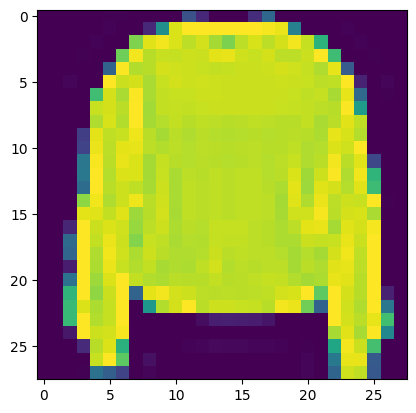

In [62]:
# plot a single sample
import matplotlib.pyplot as plt
plt.imshow(train_data[7]);


In [63]:
# Check out samples label
train_labels[7]

np.uint8(2)

In [64]:
# Create a small list so we can index onto our training labels so they're human-readable
class_names = ["T-Shirt/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]
len(class_names)

10

Text(0.5, 1.0, 'Coat')

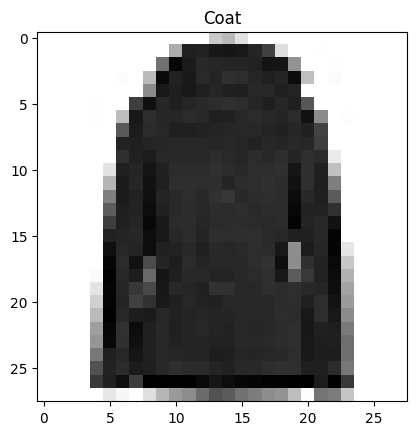

In [65]:
# Plot an example image and
index_of_choice = 2000
plt.imshow(train_data[index_of_choice], cmap=plt.cm.binary)
plt.title(class_names[train_labels[index_of_choice]])

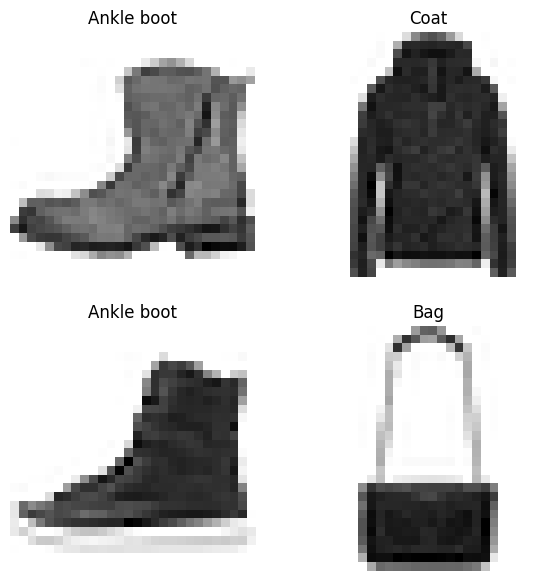

In [66]:
# plot multiple random images of fashion MNIST
import random
plt.figure(figsize=(7,7))
for i in range(4):
  ax=plt.subplot(2,2,i+1)
  rand_index = random.choice(range(len(train_data)))
  plt.imshow(train_data[rand_index], cmap=plt.cm.binary)
  plt.title(class_names[train_labels[rand_index]])
  plt.axis(False)

## Building a multi-class classification model

For our multi_class classification model, we can use a similar architeuture to our binary classifiers, however, we're going to have to tweak a few things:

* input shape = 28 * 28 (the shape of one imaage)

* output sahape = 10 (one per class of clothing)
* loss function = tf.keras.losses.CategoricalCrosstentropy()
* if your labels are one_hot encoded, use CategoricalCrosstentropy()
* if your labels are integer form use SparseCategoricalCrossentropy()
* output layer activation = Softmax (not sigmoid)

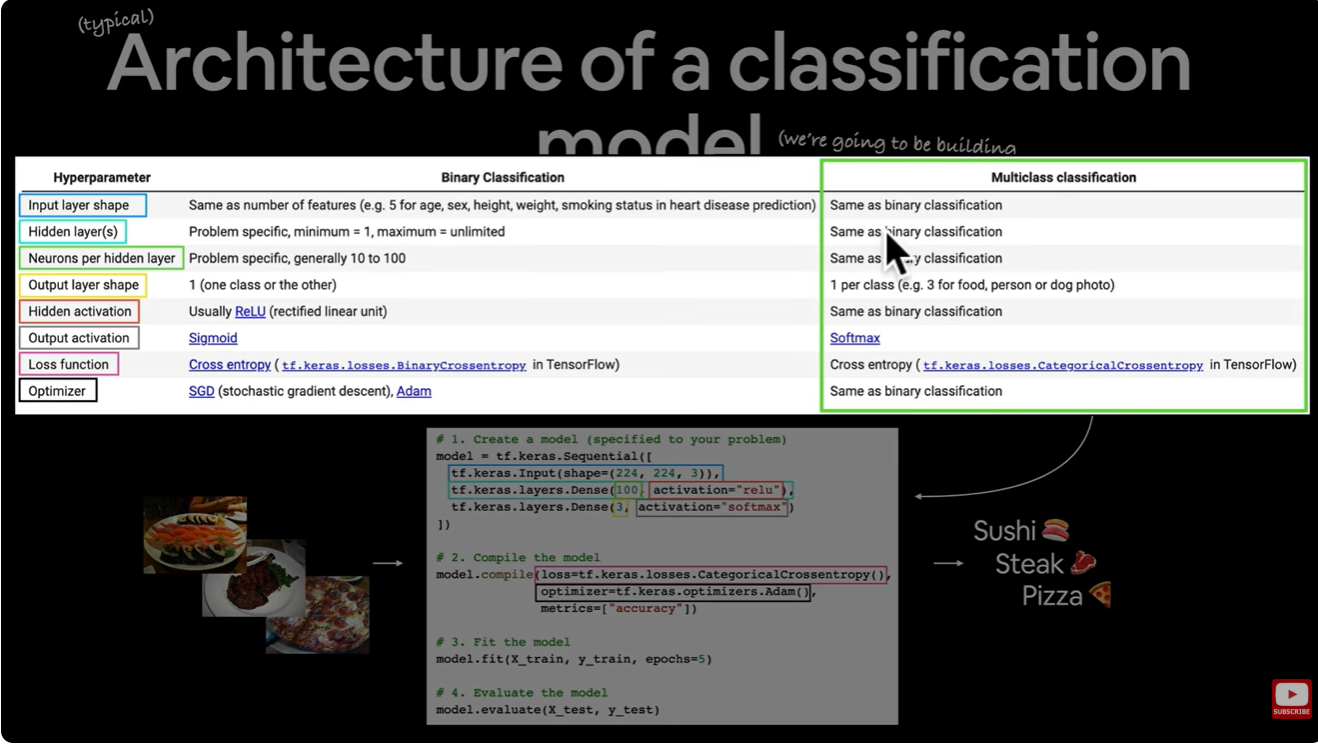


In [67]:
# Our data needs to be flattened (28 * 28 to 784)
flatten_model = tf.keras.Sequential([tf.keras.layers.Flatten(input_shape=(28,28))])
flatten_model.output_shape

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


(None, 784)

In [68]:
tf.one_hot(train_labels[:10], depth=10)

<tf.Tensor: shape=(10, 10), dtype=float32, numpy=
array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]], dtype=float32)>

In [69]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_10 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10 ,activation="softmax")
])

# Compile the model
model_10.compile(loss=tf.keras.losses.CategoricalCrossentropy(),
                 optimizer=tf.keras.optimizers.Adam(),
                 metrics=["accuracy"])

# 3. Fit the model
non_norm_history = model_10.fit(train_data,tf.one_hot(train_labels,depth=10),epochs=10, validation_data=(test_data,tf.one_hot(test_labels, depth=10)))



Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1750 - loss: 6.7786 - val_accuracy: 0.1927 - val_loss: 2.0425
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1878 - loss: 2.0366 - val_accuracy: 0.2205 - val_loss: 1.9815
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2535 - loss: 1.8612 - val_accuracy: 0.3646 - val_loss: 1.5124
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.3747 - loss: 1.4517 - val_accuracy: 0.4402 - val_loss: 1.2942
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4460 - loss: 1.2699 - val_accuracy: 0.4424 - val_loss: 1.2284
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4698 - loss: 1.1972 - val_accuracy: 0.4771 - val_loss: 1.1477
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4885 - loss: 1.1290 - val_accuracy: 0.4919 - val_loss: 1.1204
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5039 - loss: 1.1119 - 

In [70]:
# Check the model summary
model_10.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 4)              │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,632 (37.63 KB)

 Trainable params: 3,210 (12.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,422 (25.09 KB)

In [71]:
# Check the min and max values of the training data
train_data.min(), train_data.max()

(np.uint8(0), np.uint8(255))

## Neural networks prefer data to be scaled (or normalized), this means they like to have the numbers in the tensors they try to find patterns between 0 & 1

In [72]:
# we can get our training and testing data between 0 & 1 by dividing the maximum
train_data_norm = train_data/255.0
test_data_norm = test_data / 255.0


# check the min and max values of the scaled training data
train_data_norm.min(), train_data_norm.max()

(np.float64(0.0), np.float64(1.0))

In [73]:
# Now our data is normalized, let's build a model to find patterns in it

# Set the random seed
tf.random.set_seed(42)

# 1. Create the model
model_11=tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# 2. Compile the model
model_11.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                 optimizer=tf.keras.optimizers.Adam(),
                 metrics=["accuracy"])

# 3 Fit the model
norm_history = model_11.fit(train_data_norm,train_labels,epochs=10, validation_data=(train_data_norm,train_labels))


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.3261 - loss: 1.7805 - val_accuracy: 0.6606 - val_loss: 1.0591
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6761 - loss: 0.9838 - val_accuracy: 0.7207 - val_loss: 0.8277
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7223 - loss: 0.8142 - val_accuracy: 0.7379 - val_loss: 0.7538
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7400 - loss: 0.7531 - val_accuracy: 0.7498 - val_loss: 0.7162
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7523 - loss: 0.7199 - val_accuracy: 0.7602 - val_loss: 0.6917
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7608 - loss: 0.6983 - val_accuracy: 0.7656 - val_loss: 0.6773
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7680 - loss: 0.6827 - val_accuracy: 0.7847 - val_loss: 0.6613
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7793 - loss: 0.6674 - 

🔑 **Note:** Neural networks tend to prefer data in numerical form/normalized (numbers between 0 & 1).

<Axes: title={'center': 'Normalized data'}>

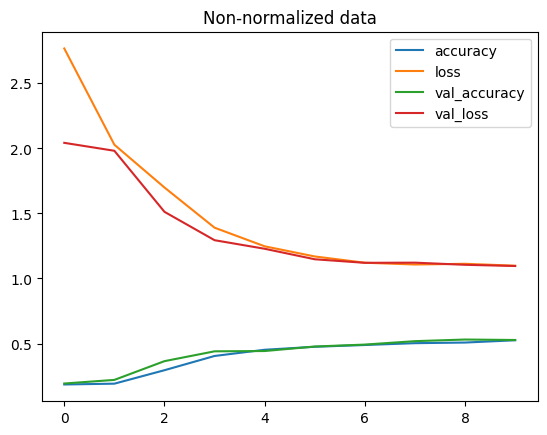

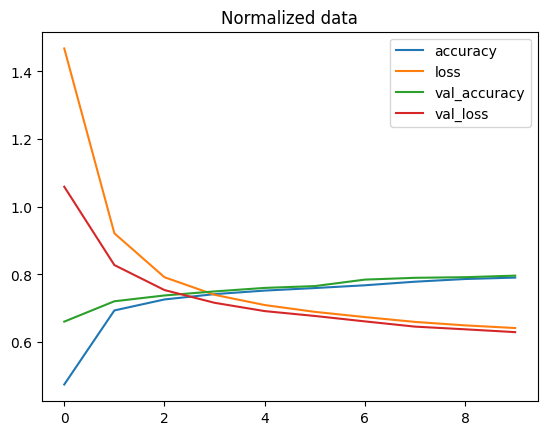

In [74]:
import pandas as pd
# Plot non-normalized data loss curves
pd.DataFrame(non_norm_history.history).plot(title="Non-normalized data")

# Plot normalized data loss curves
pd.DataFrame(norm_history.history).plot(title="Normalized data")

#

> 🔑 **Note:** The same model with even *slightly* different data can produce *dramatically* different results. So when you're comparing model's, it's important to make sure you're comparing them on the same criteria (e.g. same architecture but different data or same data but different architecture

## Finding the ideal learning rate

In [75]:
# Set random seed
tf.random.set_seed(42)

# Create the model
model_12 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# 2. Compile the model
model_12.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                 optimizer=tf.keras.optimizers.Adam(),
                 metrics=["accuracy"]
                 )

#Create the learning rate callback
lr_scheduler =tf.keras.callbacks.LearningRateScheduler(lambda epoch:1e-3 *10**(epoch/20))

# 3. Fit the model
find_history = model_12.fit(train_data_norm,train_labels,epochs=40,validation_data=(train_data,train_labels), callbacks=[lr_scheduler])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.3214 - loss: 1.7586 - val_accuracy: 0.5019 - val_loss: 58.5594 - learning_rate: 0.0010
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5715 - loss: 1.0723 - val_accuracy: 0.5751 - val_loss: 109.1486 - learning_rate: 0.0011
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7165 - loss: 0.7973 - val_accuracy: 0.5754 - val_loss: 152.8517 - learning_rate: 0.0013
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7504 - loss: 0.6920 - val_accuracy: 0.5854 - val_loss: 177.2784 - learning_rate: 0.0014
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7619 - loss: 0.6616 - val_accuracy: 0.5833 - val_loss: 191.9110 - learning_rate: 0.0016
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7675 - loss: 0.6466 - val_accuracy: 0.5868 - val_loss: 200.9061 - learning_rate: 0.0018
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accurac

Text(0.5, 1.0, 'Finding the ideal learning rate')

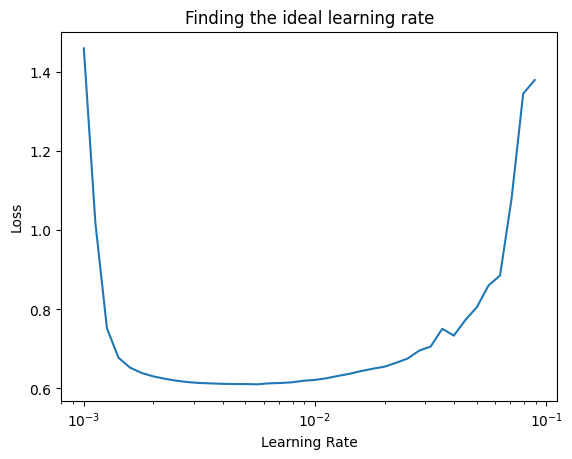

In [76]:
# Plot the learning rate decay curve

import matplotlib.pyplot as plt
lrs = 1e-3 *(10**(tf.range(40)/20))
plt.semilogx(lrs,find_history.history["loss"])
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Finding the ideal learning rate")


In [77]:
10**-3

0.001

In [78]:
# Let's refit a model with the ideal learning rate

# Set random seed
tf.random.set_seed(42)

# Create the model
model_13 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# 2. Compile the model
model_13.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                 optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                 metrics=["accuracy"])

# Fit the model
history = model_13.fit(train_data_norm,train_labels, epochs=20,validation_data=(train_data_norm,train_labels))

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.2733 - loss: 1.8543 - val_accuracy: 0.4575 - val_loss: 1.2828
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.4758 - loss: 1.2515 - val_accuracy: 0.5346 - val_loss: 1.1253
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5412 - loss: 1.1078 - val_accuracy: 0.5708 - val_loss: 1.0398
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.5880 - loss: 1.0204 - val_accuracy: 0.6070 - val_loss: 0.9587
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6202 - loss: 0.9414 - val_accuracy: 0.6328 - val_loss: 0.8922
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6389 - loss: 0.8917 - val_accuracy: 0.6403 - val_loss: 0.8662
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6509 - loss: 0.8642 - val_accuracy: 0.6462 - val_loss: 0.8510
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.6593 - loss: 0.8477 - 

from IPython.core import application
## Evaluating our multi-class classification model
To evaluate our multi-class classification model we could:
* Evaluate its performance using other classification metrics (such as a confusion matrix)

* Asses some of its prediction (through visualization)
* Improve its results (by training it for longer or changing the architecture)
* Save and export it for use in an application

let's go through the top 2



In [79]:
from sklearn.metrics import confusion_matrix
import itertools


def make_confusion_matrix(y_true,y_preds,classes=None,figsize=(10,10),text_size=15):
  # Create the confusion matrix
  cm = confusion_matrix(y_true,y_preds)
  cm_norm =cm.astype("float")/cm.sum(axis=1)[:, np.newaxis] # normalize our confusion
  n_classes = cm.shape[0]

  # Let's prettify it
  fig, ax = plt.subplots(figsize=figsize)
  # Create a matrix plot
  cax = ax.matshow(cm,cmap=plt.cm.Blues)
  fig.colorbar(cax)
  # Set the labels to be classes
  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])

  # Label the axes

  ax.set(title="confusion Matrix",
        xlabel="predicted label",
        ylabel="True label",
        xticks=np.arange(n_classes),
        yticks=np.arange(n_classes), # Corrected: Changed second xticks to yticks
        xticklabels=labels,
        yticklabels=labels)

  # Set x-axis labels to bottom

  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()

  # Adjust label size
  ax.yaxis.label.set_size(text_size)
  ax.xaxis.label.set_size(text_size)
  ax.title.set_size(text_size)

  # Set threshold for different colors
  threshold = (cm.max()+cm.min())/2

  #Plot the text on each cell
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j,i,f"{cm[i,j]} ({cm_norm[i,j]*100:.1f}%)",
            horizontalalignment="center",
            color="white" if cm[i,j] > threshold else "black",
            size =text_size)

In [80]:
# Make some prediction with our model
y_probs = model_13.predict(test_data_norm) # probs is short for "prediction probabilities"

# View the first 5 prediction
y_probs[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([[1.85912111e-04, 3.01775362e-05, 4.19782300e-05, 9.53278563e-04,
        1.18478063e-04, 1.12493634e-01, 2.53151607e-04, 3.52278262e-01,
        2.94193020e-03, 5.30703187e-01],
       [5.36784122e-04, 4.16955804e-13, 8.29673171e-01, 3.47122087e-09,
        8.52268934e-02, 4.85428418e-25, 8.40995163e-02, 0.00000000e+00,
        4.63667588e-04, 0.00000000e+00],
       [5.53865451e-04, 9.98677850e-01, 2.06222168e-08, 7.68004451e-04,
        4.24427160e-12, 8.30223681e-29, 2.76486986e-07, 0.00000000e+00,
        8.14021003e-11, 3.45715999e-25],
       [4.43091441e-04, 9.97302473e-01, 2.31346053e-08, 2.25406140e-03,
        1.65050161e-11, 1.56586070e-24, 3.80155797e-07, 6.46474406e-37,
        2.80721946e-10, 1.25616516e-18],
       [2.16650978e-01, 2.53454753e-04, 2.31390685e-01, 2.80073695e-02,
        6.08213544e-02, 1.52990787e-10, 4.51860219e-01, 1.22327351e-33,
        1.10158119e-02, 6.85333119e-28]], dtype=float32)

> 🔑**Note:** Remember to make predictions on the same kind of data your model was trained on (eg. if your model was trained on normalized data, you'll want to make predictions on normalized data).

In [81]:
y_probs[0], tf.argmax(y_probs[0]), class_names[tf.argmax(y_probs[0])]

(array([1.85912111e-04, 3.01775362e-05, 4.19782300e-05, 9.53278563e-04,
        1.18478063e-04, 1.12493634e-01, 2.53151607e-04, 3.52278262e-01,
        2.94193020e-03, 5.30703187e-01], dtype=float32),
 <tf.Tensor: shape=(), dtype=int64, numpy=9>,
 'Ankle boot')

In [82]:
# Convert all of the prediction probnabilities into integers
y_preds = y_probs.argmax(axis=1)

# View the first 10 prediction labels
y_preds[:10]

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [83]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_true=test_labels,
                 y_pred=y_preds)

array([[732,   1,  19, 125,  24,   9,  81,   0,   9,   0],
       [ 15, 914,   0,  59,   2,   2,   6,   0,   2,   0],
       [ 35,   0, 501,  17, 187,   4, 251,   0,   5,   0],
       [ 52,  26,   4, 784,  20,  27,  74,   7,   5,   1],
       [  5,   0, 141,  39, 633,   4, 166,   0,  12,   0],
       [  0,   0,   0,  11,   0, 774,   0, 128,  23,  64],
       [166,   0, 152,  76, 224,   9, 354,   0,  19,   0],
       [  0,   0,   0,   1,   0,  28,   0, 908,   0,  63],
       [  1,   0,   7,  10,  55,  47,   6,   3, 868,   3],
       [  0,   0,   0,   0,   1,  15,   0,  72,   1, 911]])

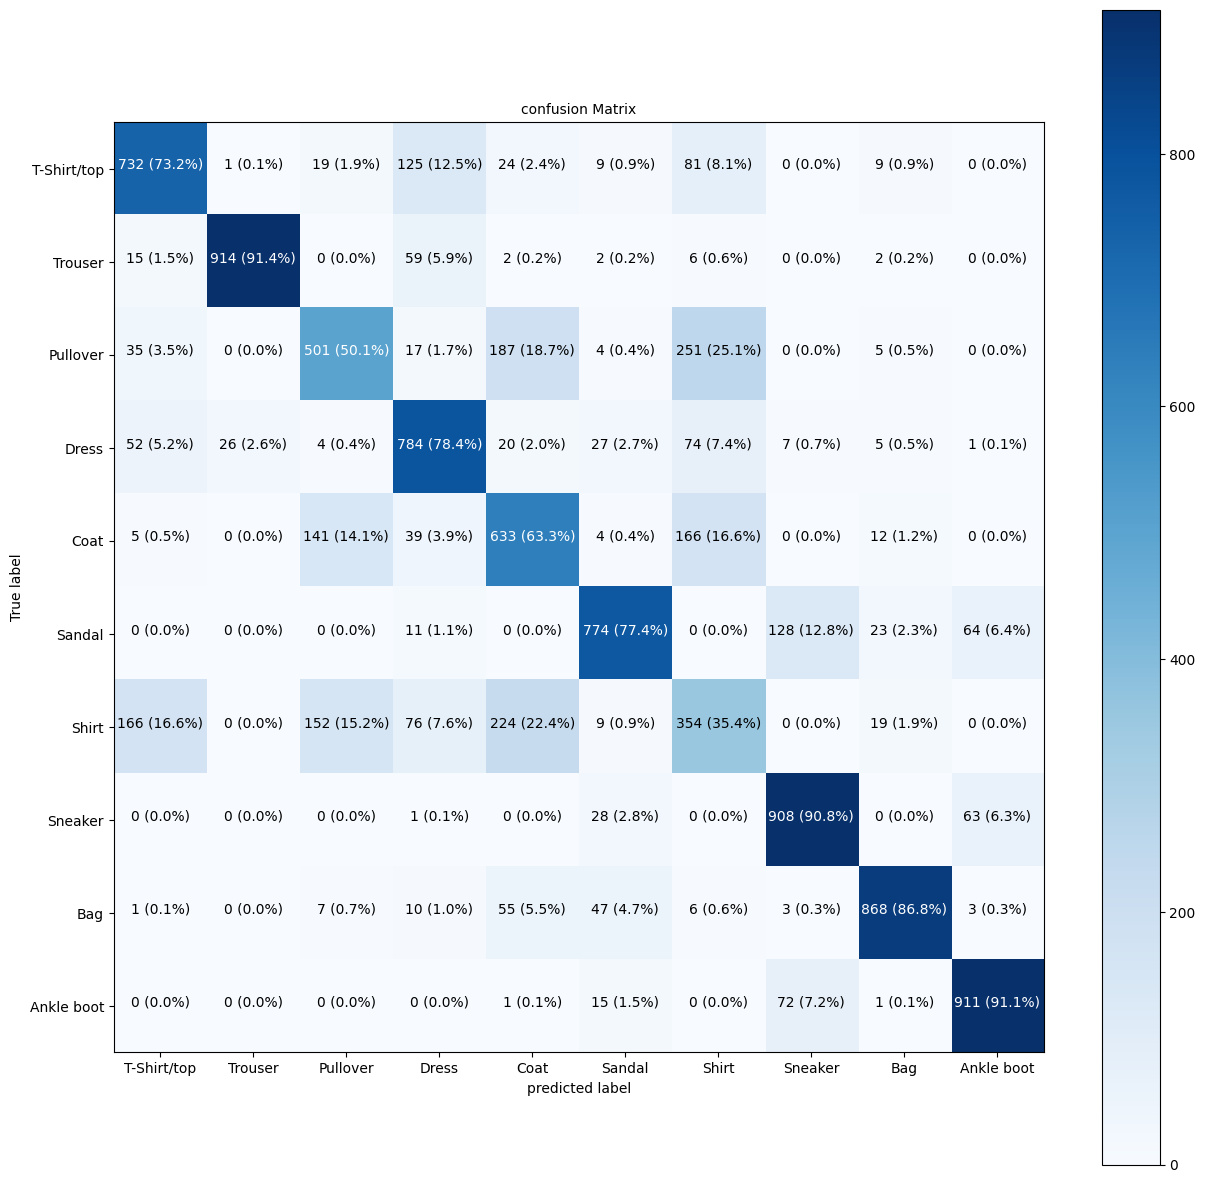

In [84]:
# Make a prettier confusion matrix
make_confusion_matrix(y_true=test_labels,
                      y_preds=y_preds,
                      classes=class_names,
                      figsize=(15,15),
                      text_size=10)

🔑**Note:** often when working with images and other forms of visual data, it's a good idea to visualize as much as possible to develop a further understanding of the data and the inputs and output of the model

how about we create a fun little function for:
* Plot a random image
* Make a prediction on said image
* label the with the truthj label & and predicted label

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


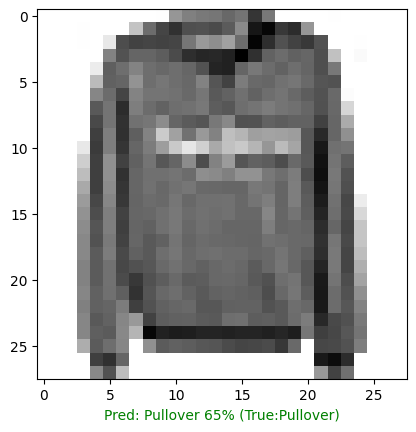

In [85]:
import random

def plot_random_image(model, images, true_labels, classes):
    """
    Picks a random, plots it and labels it with a prediction and truth label.
    """
    i = random.randint(0, len(images))
    # Create predictions and targets
    target_image=images[i]
    pred_probs = model.predict(target_image.reshape(1,28,28))
    pred_label = classes[pred_probs.argmax()]
    true_label = classes[true_labels[i]]


    # Plot the image

    plt.imshow(target_image, cmap=plt.cm.binary)

    # Change the color of the titles depending on if the prediction is right or wrong

    if pred_label == true_label:
      color = "green"
    else:
      color = "red"

    # Add xlabel information
    plt.xlabel("Pred: {} {:2.0f}% (True:{})".format(pred_label,
                                                     100*tf.reduce_max(pred_probs),
                                                    true_label),
               color=color) # Set the color to green or red based on if prediction is right or wrong
# Check out a random image as well as its prediction
plot_random_image(model=model_13,
                  images=test_data_norm, # always make prediction on the same kind of data your model was trained on
                  true_labels=test_labels,
                  classes=class_names)











**What patterns is our model learning?**

In [86]:
# Find the layers of our most recent model
model_13.layers

[<Flatten name=flatten_4, built=True>,
 <Dense name=dense_32, built=True>,
 <Dense name=dense_33, built=True>,
 <Dense name=dense_34, built=True>]

In [87]:
# Extract a particular layer
model_13.layers[1]

<Dense name=dense_32, built=True>

In [88]:
# Get the patterns of a layer in our network
weights, biases = model_13.layers[1].get_weights()

# Shape

weights, weights.shape

(array([[-0.3465481 , -0.08445799, -0.06735422,  0.5770928 ],
        [-0.42348185, -0.04134534, -0.06873712,  1.2333237 ],
        [ 0.3881287 ,  0.00377011, -0.0683776 ,  1.2013563 ],
        ...,
        [-0.4660563 , -0.06326376, -0.00531039,  0.324986  ],
        [-0.65510136, -0.00150315, -0.02500368,  0.21551019],
        [ 0.05639643,  0.05913056, -0.08019222,  0.22926594]],
       dtype=float32),
 (784, 4))

In [89]:
28*28

model_13.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 4)              │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 10)             │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,632 (37.63 KB)

 Trainable params: 3,210 (12.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,422 (25.09 KB)

## Now let's check out the bias vector

In [90]:
# Bias and biases shapes
biases, biases.shape

(array([ 1.3401611 , -0.02236493, -0.01282552,  2.6920865 ], dtype=float32),
 (4,))

Every neuron has a bias vector. Each of these is paired with a weights matrix

the bias vecyor also initiazed as zeros (at least in the case of a tensorFlow Dense layer).

The bias vector dictates how much the patterns within the corresponding weights matrix  should influence the next layer

In [91]:
model_13.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 4)              │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 10)             │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,632 (37.63 KB)

 Trainable params: 3,210 (12.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,422 (25.09 KB)

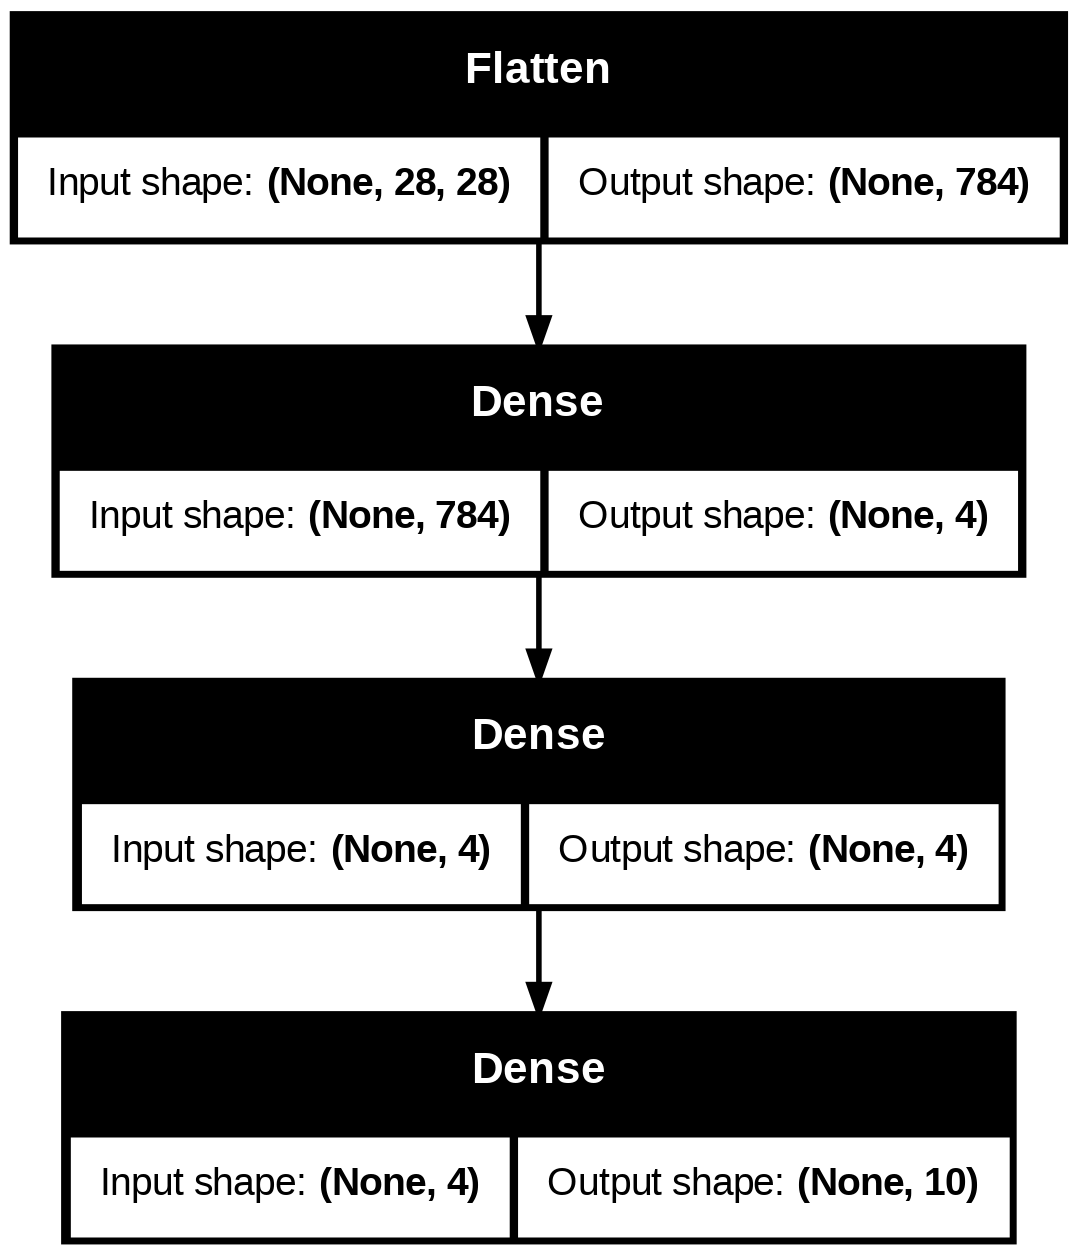

In [92]:
# Let's check out another way of viewing our deep learning models

from tensorflow.keras.utils import plot_model
plot_model(model_13, show_shapes=True)